# Baseline

__En la siguiente celda se muestran las dependencias del código, si está usando uv no debería tener problemas ejecutando el código__

In [1]:
import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sys
import os
from pathlib import Path
from pyspark.sql.window import Window
from pyspark.sql import functions as F

root = Path.cwd().parent 
sys.path.append(str(root))

from minio_utils import MinioSparkClient

from setup import setenv
setenv()

spark = MinioSparkClient(
    endpoint=os.getenv("MINIO_ENDPOINT", "").replace("http://", "").replace("https://", ""),
    access_key=os.getenv("MINIO_ACCESS_KEY"),
    secret_key=os.getenv("MINIO_SECRET_KEY"),
    bucket_name="pd2",
    base_dir="cityenjoyer",
    memory = 16,
    heapsize = 8,
    num_part = 2000,
    verbose=True
)
spark.connect()

26/03/19 16:50:02 WARN Utils: Your hostname, danpanto-OMEN-Gaming-Laptop-16-ap0xxx resolves to a loopback address: 127.0.1.1; using 192.168.4.174 instead (on interface eno1)
26/03/19 16:50:02 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
https://mmlspark.azureedge.net/maven added as a remote repository with the name: repo-1
Ivy Default Cache set to: /home/danpanto/.ivy2/cache
The jars for the packages stored in: /home/danpanto/.ivy2/jars
com.microsoft.azure#synapseml_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-eaed0e14-d2f6-46c5-bcdf-2ac3c610fca3;1.0
	confs: [default]


:: loading settings :: url = jar:file:/home/danpanto/Desktop/C-ity-enjoyers/.venv/lib/python3.13/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found com.microsoft.azure#synapseml_2.12;1.1.2 in central
	found com.microsoft.azure#synapseml-core_2.12;1.1.2 in central
	found org.apache.spark#spark-avro_2.12;3.5.0 in central
	found org.tukaani#xz;1.9 in central
	found commons-lang#commons-lang;2.6 in central
	found org.scalactic#scalactic_2.12;3.2.14 in central
	found org.scala-lang#scala-reflect;2.12.15 in central
	found io.spray#spray-json_2.12;1.3.5 in central
	found com.jcraft#jsch;0.1.54 in central
	found org.apache.httpcomponents.client5#httpclient5;5.1.3 in central
	found org.apache.httpcomponents.core5#httpcore5;5.1.3 in central
	found org.apache.httpcomponents.core5#httpcore5-h2;5.1.3 in central
	found org.slf4j#slf4j-api;1.7.25 in central
	found commons-codec#commons-codec;1.15 in central
	found org.apache.httpcomponents#httpmime;4.5.13 in central
	found org.apache.httpcomponents#httpclient;4.5.13 in central
	found org.apache.httpcomponents#httpcore;4.4.13 in central
	found commons-logging#commons-logging;1.2 in central

## Explicación de la baseline:

Para este projecto, independientemente de la variable a predecir utilizaremos el *Moving average forecast*. Basicamente consiste en suponer que el siguiente step es la media de la ventana de entrada. Esta baseline encaja muy bien con nuestros modelos ya que nuestro input siempre son ventanas temporales de tamaño fijo.

El mayor pro que tiene este baseline es que no sufre tanto con datos que cambian su tendencia de forma frecuente, cosa que con los datos de los taxis ocurre con bastante frecuencia.

En la siguiente imagen se puede ver cómo predice con un dataset arbitrario


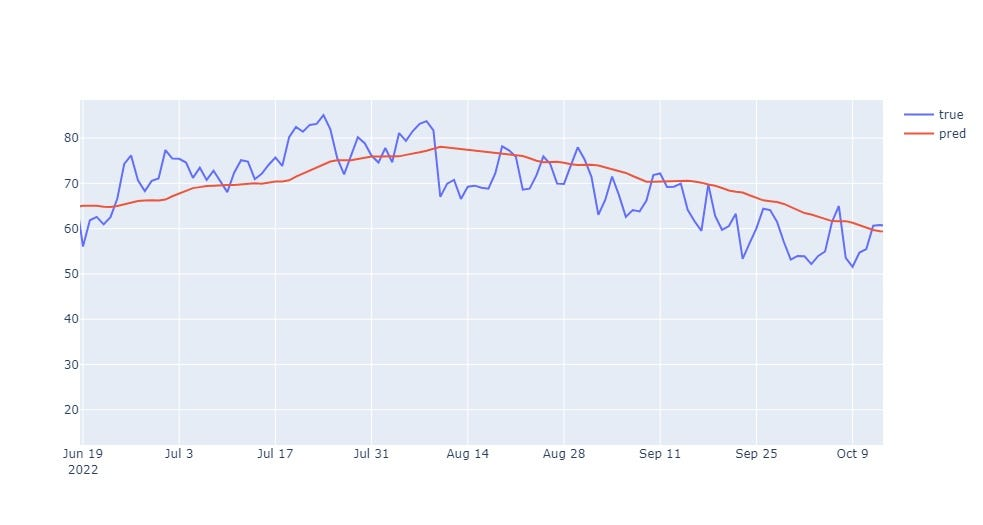

Fuente:
https://towardsdatascience.com/baseline-models-in-time-series-c76d44a826b3/

## Implementación con nuestros datos

### Descarga de los datos

In [2]:
df = spark.read_parquet("prepared_for_model/20260318_143014_agg.parquet")

df.show()

+--------+------------+-------------------+------+------------+----------+---------+----------+----+---+--------------------+--------------------+-------------------+-------------------+
|VendorID|PULocationID|          timestamp|demand|avg_distance|avg_amount| Latitude| Longitude|hour|dow|            hour_sin|            hour_cos|            dow_sin|            dow_cos|
+--------+------------+-------------------+------+------------+----------+---------+----------+----+---+--------------------+--------------------+-------------------+-------------------+
|       0|         262|2023-06-01 00:00:00|     4|      4377.0|    1447.5|40.775932| -73.94651|   0|  5|                 0.0|                 1.0|-0.9749279121818236|-0.2225209339563146|
|       0|         113|2023-06-01 05:00:00|     4|    17786.75|   4915.75| 40.73258| -73.99431|   5|  5|  0.9659258262890682| 0.25881904510252096|-0.9749279121818236|-0.2225209339563146|
|       0|         239|2023-06-01 06:00:00|    63|     8703.19| 3

### Implementación del baseline

In [3]:
# Definimos una ventana para separar por servicio y zona
window_spec = Window.partitionBy("VendorID", "PULocationID") \
                    .orderBy("timestamp") \
                    .rowsBetween(-5, -1) 

# Aplicamos el baseline
df_forecast = df.withColumn(
    "prediction", 
    F.avg("demand").over(window_spec)
)

df_forecast.select("timestamp", "VendorID", "PULocationID", "demand", "prediction").show()

+-------------------+--------+------------+------+----------+
|          timestamp|VendorID|PULocationID|demand|prediction|
+-------------------+--------+------------+------+----------+
|2021-01-09 12:00:00|       0|           5|     1|      NULL|
|2021-01-11 09:00:00|       0|           5|     1|       1.0|
|2021-01-12 08:00:00|       0|           5|     1|       1.0|
|2021-01-13 08:00:00|       0|           5|     1|       1.0|
|2021-01-14 08:00:00|       0|           5|     1|       1.0|
|2021-01-15 08:00:00|       0|           5|     1|       1.0|
|2021-01-16 10:00:00|       0|           5|     1|       1.0|
|2021-01-17 12:00:00|       0|           5|     1|       1.0|
|2021-01-19 11:00:00|       0|           5|     1|       1.0|
|2021-01-20 19:00:00|       0|           5|     1|       1.0|
|2021-01-21 06:00:00|       0|           5|     1|       1.0|
|2021-01-25 06:00:00|       0|           5|     1|       1.0|
|2021-01-26 06:00:00|       0|           5|     1|       1.0|
|2021-01

### Evaluemos el rendimiento

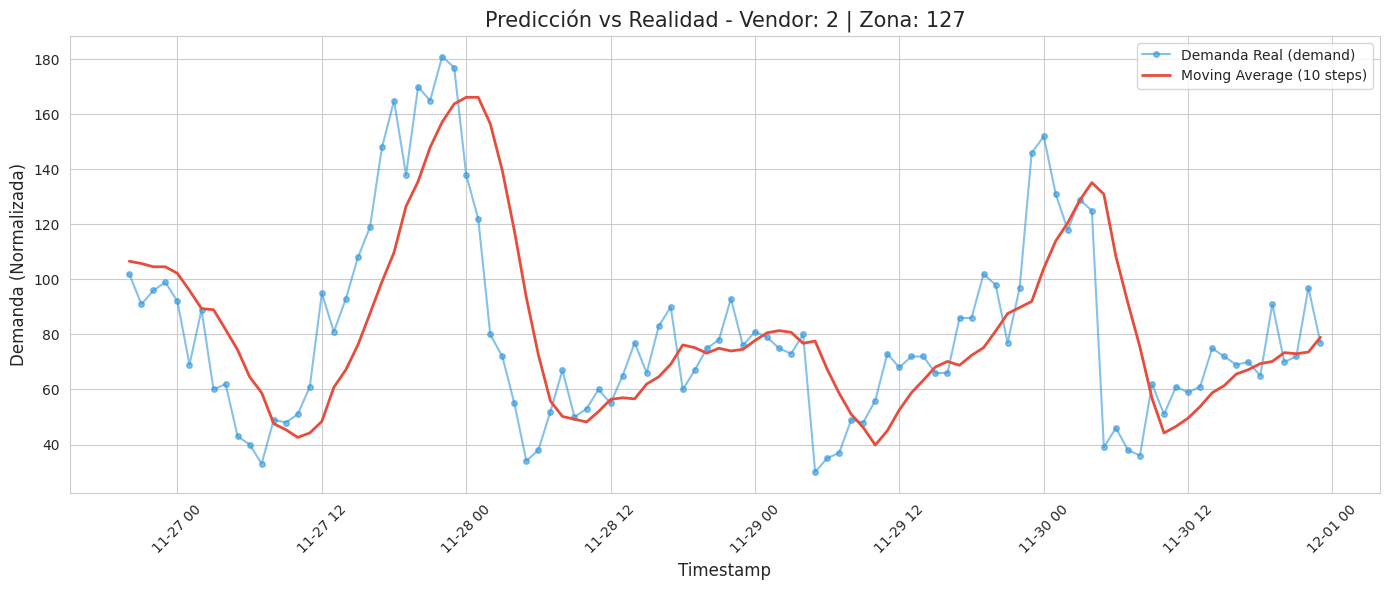

In [4]:
def visualizar_demanda(df_spark, vendor_id, location_id):
    # Filtramos los datos en Spark para que la transferencia a Pandas sea ligera
    df_plot = (df_spark
               .filter((F.col("VendorID") == vendor_id) & (F.col("PULocationID") == location_id))
               .orderBy(F.col("timestamp").desc())
               .limit(100)                     
               .toPandas())

    if df_plot.empty:
        print(f"No hay datos para Vendor {vendor_id} en la zona {location_id}")
        return

    # Configuración del gráfico
    plt.figure(figsize=(14, 6))
    sns.set_style("whitegrid")

    # Graficamos la demanda real
    plt.plot(df_plot['timestamp'], df_plot['demand'], 
             label='Demanda Real (demand)', color='#3498db', alpha=0.6, marker='o', markersize=4)

    # Graficamos la predicción (Media Móvil)
    plt.plot(df_plot['timestamp'], df_plot['prediction'], 
             label='Moving Average (10 steps)', color='#e74c3c', linewidth=2)

    # Personalización
    plt.title(f'Predicción vs Realidad - Vendor: {vendor_id} | Zona: {location_id}', fontsize=15)
    plt.xlabel('Timestamp', fontsize=12)
    plt.ylabel('Demanda (Normalizada)', fontsize=12)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    plt.show()

visualizar_demanda(df_forecast, vendor_id=2, location_id=127)

In [7]:
from pyspark.ml.evaluation import RegressionEvaluator
import pyspark.sql.functions as F

def calcular_rmse(df_spark):
    
    # 2. Configuramos el evaluador
    # 'label' es el valor real, 'prediction' es tu media móvil
    evaluator = RegressionEvaluator(
        labelCol="demand", 
        predictionCol="prediction", 
        metricName="mae"
    )
    
    # 3. Calculamos el error
    mae = evaluator.evaluate(df_spark)
    
    print(f"--- Evaluación")
    print(f"MAE: {mae:.4f}")
    
    return mae

valor_rmse = calcular_rmse(df_forecast.dropna())

--- Evaluación
MAE: 17.5369
